# Presentation visualisation: Final Top100 segment distribution

Presentation-only visualisation of the existing official shortlist. This notebook reads the final Top100 and the existing industry mapping. It does not recompute ranking scores or write official recommendation tables.

The Top100 is distributed across all five segments, with no single segment dominating the shortlist. Counts describe selected merchants only, not market size, industry growth or future potential.

Run from the repository root or `member5_ranking/`. Exported PNG is 3600 × 2220 pixels (300 dpi); SVG uses vector paths for portable font appearance. Colours follow the supplied beige/navy slide reference. Full segment names wrap without abbreviation.


In [1]:
from pathlib import Path
import textwrap
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(p for p in (cwd, *cwd.parents)
                    if (p / "member5_ranking/results/final_top_100.csv").is_file())
TOP100_PATH = PROJECT_ROOT / "member5_ranking/results/final_top_100.csv"
MAPPING_PATH = PROJECT_ROOT / "member3_industry_growth/results/category_to_group_mapping.csv"
RESULTS_DIR = PROJECT_ROOT / "member5_ranking/results"

top100 = pd.read_csv(TOP100_PATH, dtype={"merchant_abn": str})
mapping = pd.read_csv(MAPPING_PATH)
assert len(top100) == 100 and top100["merchant_abn"].is_unique
assert top100["final_rank"].between(1, 100).all()
selected = top100[["merchant_abn", "merchant_category"]].merge(
    mapping[["merchant_category", "industry_group"]],
    on="merchant_category", how="left", validate="many_to_one")
assert selected["industry_group"].notna().all()
# Alphabetical order breaks equal-count ties deterministically.
counts = selected.groupby("industry_group", sort=True).size().sort_values(
    ascending=False, kind="stable")
expected = {
    "Digital, Technology & Communications": 30,
    "Home, Garden & Living": 25,
    "Art, Gifts, Jewellery & Fashion": 16,
    "Mobility, Health & Specialist Services": 16,
    "Creative, Books & Leisure": 13,
}
assert counts.to_dict() == expected, "Official results changed: review slide figures before exporting."
assert counts.sum() == 100
print("Source:", TOP100_PATH)
print("Industry mapping:", MAPPING_PATH)
display(counts.rename("Selected merchants").to_frame())

Source: /Users/xiexinyu/Desktop/MAST30034-Project-2-Group-50/member5_ranking/results/final_top_100.csv
Industry mapping: /Users/xiexinyu/Desktop/MAST30034-Project-2-Group-50/member3_industry_growth/results/category_to_group_mapping.csv


,Selected merchants
industry_group,
"Digital, Technology & Communications",30
"Home, Garden & Living",25
"Art, Gifts, Jewellery & Fashion",16
"Mobility, Health & Specialist Services",16
"Creative, Books & Leisure",13


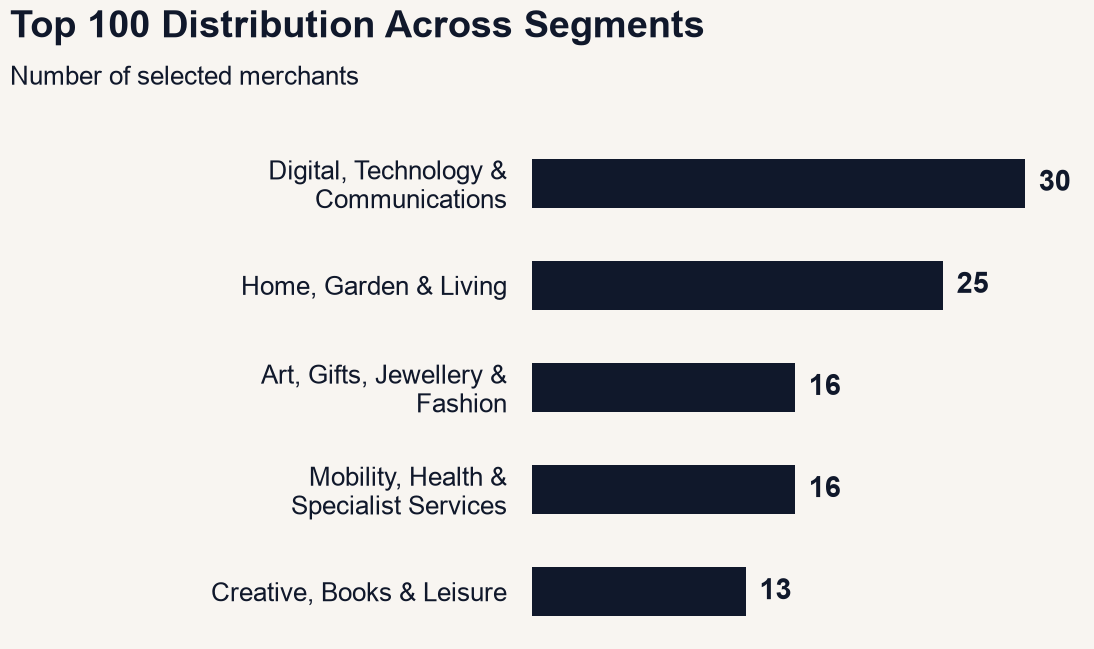

PNG: /Users/xiexinyu/Desktop/MAST30034-Project-2-Group-50/member5_ranking/results/presentation_top100_segment_distribution.png
SVG: /Users/xiexinyu/Desktop/MAST30034-Project-2-Group-50/member5_ranking/results/presentation_top100_segment_distribution.svg


In [2]:
BEIGE = "#F8F5F1"
NAVY = "#10182B"
labels = [textwrap.fill(name, width=27, break_long_words=False,
                        break_on_hyphens=False) for name in counts.index]
PNG_PATH = RESULTS_DIR / "presentation_top100_segment_distribution.png"
SVG_PATH = RESULTS_DIR / "presentation_top100_segment_distribution.svg"

with plt.rc_context({"font.family": "Arial", "text.color": NAVY,
                     "ytick.color": NAVY, "svg.fonttype": "path"}):
    fig, ax = plt.subplots(figsize=(12, 7.4), facecolor=BEIGE)
    fig.subplots_adjust(left=0.49, right=0.95, top=0.76, bottom=0.08)
    ax.set_facecolor(BEIGE)
    bars = ax.barh(labels, counts.to_numpy(), color=NAVY, height=0.48)
    ax.invert_yaxis()
    ax.set_xlim(0, counts.max() * 1.12)
    ax.bar_label(bars, padding=10, fontsize=21, fontweight="bold", color=NAVY)
    ax.xaxis.set_visible(False)
    ax.tick_params(axis="y", length=0, pad=18, labelsize=19)
    for spine in ax.spines.values():
        spine.set_visible(False)
    fig.text(0.055, 0.93, "Top 100 Distribution Across Segments",
             fontsize=27, fontweight="bold", ha="left", va="top")
    fig.text(0.055, 0.855, "Number of selected merchants",
             fontsize=19, ha="left", va="top")
    # SVG glyph paths preserve appearance even without Arial on the destination computer.
    fig.savefig(PNG_PATH, dpi=300, facecolor=BEIGE)
    fig.savefig(SVG_PATH, facecolor=BEIGE)
    plt.show()
    plt.close(fig)
print("PNG:", PNG_PATH)
print("SVG:", SVG_PATH)

## Business value comparison: Top 100 vs Random 100 vs Bottom 100

This presentation-only comparison uses the formal eligible ranking base and existing final Top100.
Bottom100 means the lowest-ranked eligible merchants, not the lowest revenue merchants.
The historical BNPL fee-revenue proxy is observed `total_revenue × merchant_take_rate_pct / 100`.
It is not future revenue, incremental BNPL revenue or net profit.

Random100 uses 1,000 uniform samples without replacement within each sample, with seed 20261009.
Samples are independent draws from the full eligible pool, so merchants may recur across draws.
Typical Random100 is the median simulated total. Its 5th–95th percentile range describes random
selection variability, not a confidence interval or a future revenue forecast.

This is an in-sample descriptive comparison. Historical revenue is already a scoring input;
outperformance against random or bottom-ranked choices does not independently validate the
ranking, establish optimal weights, or prove superiority over a revenue-only strategy.
No ranking scores, eligibility criteria or official recommendation files are changed.


In [3]:
import numpy as np
from IPython.display import Markdown

RANKING_BASE_PATH = RESULTS_DIR / "ranking_analysis_base.csv"
value_pool = pd.read_csv(RANKING_BASE_PATH, dtype={"merchant_abn": str})
formal_top = pd.read_csv(TOP100_PATH, dtype={"merchant_abn": str})
assert value_pool.merchant_abn.is_unique
assert value_pool.has_merchant_master_record.eq(True).all()
assert value_pool.final_rank.notna().all() and value_pool.final_rank.is_unique
assert len(value_pool) == 4026 and len(formal_top) == 100
# Stable identifier order makes simulation reproducible even if CSV row order changes.
value_pool = value_pool.sort_values("merchant_abn").reset_index(drop=True)
fee_column = "estimated_bnpl_revenue"
assert np.isfinite(value_pool[fee_column]).all() and value_pool[fee_column].ge(0).all()
np.testing.assert_allclose(value_pool[fee_column],
    value_pool.total_revenue * value_pool.merchant_take_rate_pct / 100, rtol=1e-10)
assert set(formal_top.merchant_abn) == set(value_pool.nsmallest(100, "final_rank").merchant_abn)
value_top = value_pool.loc[value_pool.merchant_abn.isin(formal_top.merchant_abn)].copy()
np.testing.assert_allclose(formal_top.set_index("merchant_abn").loc[value_top.merchant_abn, fee_column], value_top[fee_column])
value_bottom = value_pool.nlargest(100, "final_rank").copy()
assert len(value_top) == len(value_bottom) == 100
assert set(value_top.merchant_abn).isdisjoint(value_bottom.merchant_abn)

RANDOM_SEED = 20261009
N_SIMULATIONS = 1000
SAMPLE_SIZE = 100
rng = np.random.default_rng(RANDOM_SEED)
fee_values = value_pool[fee_column].to_numpy()
sample_indices = np.stack([rng.choice(len(value_pool), size=SAMPLE_SIZE, replace=False)
                           for _ in range(N_SIMULATIONS)])
assert all(len(np.unique(indices)) == SAMPLE_SIZE for indices in sample_indices)
random_totals = fee_values[sample_indices].sum(axis=1)
random_median = float(np.median(random_totals))
random_mean = float(np.mean(random_totals))
random_p05, random_p95 = np.quantile(random_totals, [.05, .95])
top_total = float(value_top[fee_column].sum())
bottom_total = float(value_bottom[fee_column].sum())
assert random_median > 0 and bottom_total > 0

simulation_distribution = pd.DataFrame({
    "simulation_id": np.arange(1, N_SIMULATIONS + 1),
    "random_seed": RANDOM_SEED, "sample_size": SAMPLE_SIZE,
    "eligible_merchant_count": len(value_pool),
    "total_historical_bnpl_fee_revenue_proxy_aud": random_totals,
})
comparison_summary = pd.DataFrame([
    dict(group="Our Top 100", total_basis="Observed total of formal Top100",
         displayed_total_aud=top_total, per_merchant_mean_aud=value_top[fee_column].mean(),
         per_merchant_median_aud=value_top[fee_column].median()),
    dict(group="Typical Random 100", total_basis="Median total across 1000 random selections",
         displayed_total_aud=random_median, random_total_mean_aud=random_mean,
         random_total_median_aud=random_median, random_total_p05_aud=random_p05,
         random_total_p95_aud=random_p95),
    dict(group="Bottom 100", total_basis="Observed total of lowest final-ranked 100",
         displayed_total_aud=bottom_total, per_merchant_mean_aud=value_bottom[fee_column].mean(),
         per_merchant_median_aud=value_bottom[fee_column].median()),
])
comparison_summary["merchant_count_per_selection"] = SAMPLE_SIZE
comparison_summary["eligible_merchant_count"] = len(value_pool)
comparison_summary["random_simulation_count"] = N_SIMULATIONS
comparison_summary["random_seed"] = RANDOM_SEED
comparison_summary["top100_to_group_total_ratio"] = top_total / comparison_summary.displayed_total_aud
comparison_summary["top100_minus_group_total_aud"] = top_total - comparison_summary.displayed_total_aud
SUMMARY_PATH = RESULTS_DIR / "top100_vs_random_vs_bottom_summary.csv"
SIMULATION_PATH = RESULTS_DIR / "top100_random_simulation_distribution.csv"
comparison_summary.to_csv(SUMMARY_PATH, index=False)
simulation_distribution.to_csv(SIMULATION_PATH, index=False)
display(comparison_summary)
takeaway = (f"Our selected Top 100 captures {top_total/random_median:.1f}× the historical BNPL fee-revenue proxy "
            f"of a typical random selection and {top_total/bottom_total:,.0f}× that of the Bottom 100.")
display(Markdown("**Slide takeaway:** " + takeaway))
print("Source:", RANKING_BASE_PATH)
print("Formal shortlist:", TOP100_PATH)


,group,total_basis,displayed_total_aud,per_merchant_mean_aud,per_merchant_median_aud,random_total_mean_aud,random_total_median_aud,random_total_p05_aud,random_total_p95_aud,merchant_count_per_selection,eligible_merchant_count,random_simulation_count,random_seed,top100_to_group_total_ratio,top100_minus_group_total_aud
0,Our Top 100,Observed total of formal Top100,2.549483e+07,254948.303464,214181.914473,NaN,NaN,NaN,NaN,100,4026,1000,20261009,1.000000,0.000000e+00
1,Typical Random 100,Median total across 1000 random selections,2.330973e+06,NaN,NaN,2.388749e+06,2.330973e+06,1.570267e+06,3.381642e+06,100,4026,1000,20261009,10.937419,2.316386e+07
2,Bottom 100,Observed total of lowest final-ranked 100,7.291155e+04,729.115474,660.048731,NaN,NaN,NaN,NaN,100,4026,1000,20261009,349.667937,2.542192e+07


**Slide takeaway:** Our selected Top 100 captures 10.9× the historical BNPL fee-revenue proxy of a typical random selection and 350× that of the Bottom 100.

Source: /Users/xiexinyu/Desktop/MAST30034-Project-2-Group-50/member5_ranking/results/ranking_analysis_base.csv
Formal shortlist: /Users/xiexinyu/Desktop/MAST30034-Project-2-Group-50/member5_ranking/results/final_top_100.csv


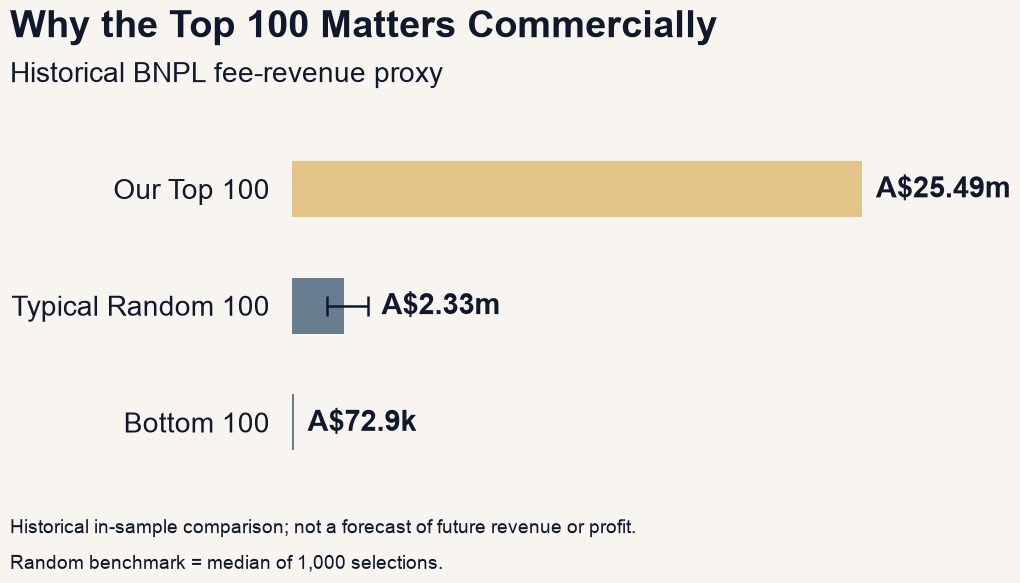

In [4]:
VALUE_PNG_PATH = RESULTS_DIR / "presentation_top100_business_value_comparison.png"
VALUE_SVG_PATH = RESULTS_DIR / "presentation_top100_business_value_comparison.svg"
value_labels = ["Our Top 100", "Typical Random 100", "Bottom 100"]
values_millions = np.array([top_total, random_median, bottom_total]) / 1e6
GOLD = "#E2C489"
BLUE_GREY = "#697D91"
with plt.rc_context({"font.family": "Arial", "text.color": NAVY,
                     "ytick.color": NAVY, "svg.fonttype": "path"}):
    fig, ax = plt.subplots(figsize=(12, 6.5), facecolor=BEIGE)
    fig.subplots_adjust(left=.29, right=.86, top=.72, bottom=.23)
    ax.set_facecolor(BEIGE)
    ax.barh(range(3), values_millions, color=[GOLD, BLUE_GREY, BLUE_GREY], height=.48)
    ax.set_yticks(range(3), value_labels, fontsize=20)
    ax.invert_yaxis()
    ax.set_xlim(0, values_millions.max()*1.20)
    ax.tick_params(axis="y", length=0, pad=16)
    ax.xaxis.set_visible(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.errorbar(random_median/1e6, 1,
                xerr=np.array([[random_median-random_p05], [random_p95-random_median]])/1e6,
                fmt="none", ecolor=NAVY, capsize=7, elinewidth=1.8, capthick=1.8)
    for i, amount in enumerate([top_total, random_median, bottom_total]):
        # Random annotation clears the upper range endpoint.
        end = random_p95/1e6 if i==1 else amount/1e6
        label = f"A${amount/1e6:.2f}m" if amount>=1e6 else f"A${amount/1e3:.1f}k"
        ax.annotate(label, (end, i), xytext=(10,0), textcoords="offset points",
                    ha="left", va="center", fontsize=21, fontweight="bold", color=NAVY)
    fig.text(.055,.93,"Why the Top 100 Matters Commercially",fontsize=27,fontweight="bold",va="top")
    fig.text(.055,.85,"Historical BNPL fee-revenue proxy",fontsize=20,va="top")
    fig.text(.055,.125,"Historical in-sample comparison; not a forecast of future revenue or profit.",fontsize=14)
    fig.text(.055,.07,"Random benchmark = median of 1,000 selections.",fontsize=14)
    fig.savefig(VALUE_PNG_PATH,dpi=300,facecolor=BEIGE)
    fig.savefig(VALUE_SVG_PATH,facecolor=BEIGE)
    plt.show()
    plt.close(fig)


In [5]:
# End-of-run checks and requested validation report.
assert len(simulation_distribution) == 1000
assert np.isfinite(random_totals).all()
assert random_p05 <= random_median <= random_p95
pd.testing.assert_frame_equal(pd.read_csv(RANKING_BASE_PATH, dtype={"merchant_abn": str}).sort_values("merchant_abn").reset_index(drop=True), value_pool)
pd.testing.assert_frame_equal(pd.read_csv(TOP100_PATH, dtype={"merchant_abn": str}), formal_top)
for key, value in {
    "Eligible merchant count": len(value_pool), "Top100 count": len(value_top),
    "Bottom100 count": len(value_bottom), "Random simulation count": len(random_totals),
    "Random seed": RANDOM_SEED, "Top100 total (AUD)": top_total,
    "Median Random100 total (AUD)": random_median, "Mean Random100 total (AUD)": random_mean,
    "Random100 5th percentile (AUD)": random_p05, "Random100 95th percentile (AUD)": random_p95,
    "Bottom100 total (AUD)": bottom_total,
    "Top100 / median Random100": top_total/random_median,
    "Top100 / Bottom100": top_total/bottom_total,
    "Top100 minus median Random100 (AUD)": top_total-random_median,
    "Top100 minus Bottom100 (AUD)": top_total-bottom_total,
}.items():
    print(f"{key}: {value:,.4f}" if isinstance(value,float) else f"{key}: {value}")
for path in [SUMMARY_PATH,SIMULATION_PATH,VALUE_PNG_PATH,VALUE_SVG_PATH]:
    assert path.is_file()
    print("Created:",path)


Eligible merchant count: 4026
Top100 count: 100
Bottom100 count: 100
Random simulation count: 1000
Random seed: 20261009
Top100 total (AUD): 25,494,830.3464
Median Random100 total (AUD): 2,330,973.1779
Mean Random100 total (AUD): 2,388,748.8336
Random100 5th percentile (AUD): 1,570,266.9403
Random100 95th percentile (AUD): 3,381,642.0348
Bottom100 total (AUD): 72,911.5474
Top100 / median Random100: 10.9374
Top100 / Bottom100: 349.6679
Top100 minus median Random100 (AUD): 23,163,857.1685
Top100 minus Bottom100 (AUD): 25,421,918.7990
Created: /Users/xiexinyu/Desktop/MAST30034-Project-2-Group-50/member5_ranking/results/top100_vs_random_vs_bottom_summary.csv
Created: /Users/xiexinyu/Desktop/MAST30034-Project-2-Group-50/member5_ranking/results/top100_random_simulation_distribution.csv
Created: /Users/xiexinyu/Desktop/MAST30034-Project-2-Group-50/member5_ranking/results/presentation_top100_business_value_comparison.png
Created: /Users/xiexinyu/Desktop/MAST30034-Project-2-Group-50/member5_ran